In [2]:
# some imports
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
plt.rc('font', size=12) 
plt.rc('figure', figsize = (12, 5))

# Settings for the visualizations
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2,'font.family': [u'times']})

import pandas as pd
pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 50)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# ===== Practica 3 : Boosting =====

En esta práctica volveremos a abordar un problema de clasificación a partir de un dataset dado.

Esta vez tendremos que crear nuestro propio modelo de Boosting para solucionar el problema y tendremos que compararlo con diferentes clasificadores para ver su rendimiento.


Noviembre 2025

Andrés Río y Albert Digon


# Clase BoostingClassifier

Creación de nuestro propio modelo de Boosting. Nuestro modelo funciona de la siguiente manera :

## init(self, X, y, w, max_depth=2, subsample_frac=1.0, weight_clip=None)

Guarda los datos

- X: matriz de características.
- y: etiquetas 0/1.

En el init, los pesos por muestra se normalizan para usarse como sample_weight del boosting y para poder actualizarlos iterativamente. A partir de esos pesos iniciales se calculan pesos de clase fijos (w0 y w1), obtenidos como la media de los pesos de cada clase. Estos pesos de clase se usan en la Weighted Binary Cross Entropy, mientras que los pesos por muestra se usan y actualizan durante el boosting. Así se separan correctamente ambos tipos de ponderación.

Además, el constructor recibe hiperparámetros que controlan la capacidad y el comportamiento del boosting:

- max_depth: profundidad máxima de cada árbol débil (por defecto 2).
- subsample_frac: fracción de muestras usada para entrenar cada árbol (1.0 → todas, <1.0 → submuestreo tipo stochastic boosting).
- weight_clip: valor máximo opcional para los pesos de las muestras después de actualizarlos (sirve para evitar que unos pocos ejemplos dominen todo el entrenamiento).

Inicializas todo lo necesario para hacer boosting sobre un dataset desbalanceado:

- pesos por muestra (para el boosting secuencial),
- pesos por clase (para la pérdida WBCE),
- los hiperparámetros que controlan la complejidad del modelo (profundidad, subsampling y estabilidad de los pesos).

## _weighted_binary_cross_entropy(self, y_true, p_pred)

Es la función de coste que el boosting intenta minimizar. No usa los sample weights, solo el class weight.

- Penaliza más los errores en la clase minoritaria (gracias a los pesos w0, w1).
- Trabaja con probabilidades, por eso es adecuada para clasificación probabilística.
- Devuelve una pérdida por muestra, que luego se usa para actualizar los pesos de boosting.

## fit(self, num_trees: int, shrinkage: float = 1.0)

Para cada iteración m de 0 a num_trees - 1:

1. Submuestreo opcional del dataset

- Si subsample_frac < 1.0, se selecciona aleatoriamente una fracción de las muestras (por ejemplo, el 80%) sin reemplazo.
- El árbol de esa iteración solo se entrena con ese subconjunto y los pesos correspondientes.
- Esto introduce aleatoriedad controlada y reduce el sobreajuste (similar a stochastic gradient boosting).

2. Entrena un árbol débil con los pesos actuales

- Crea un DecisionTreeClassifier poco profundo con max_depth controlable (por ejemplo 2 o 3).
- Lo entrena con sample_weight igual a los pesos por muestra actuales.
- Así, las muestras más pesadas influyen más en el árbol: el árbol se centra en los ejemplos difíciles o importantes según la historia del boosting.

3. Obtiene las probabilidades del árbol

- proba = tree.predict_proba(self.X)[:, 1].
- Probabilidad de clase 1 para cada muestra del conjunto de entrenamiento.

4. Calcula la pérdida WBCE por muestra

- losses = self._weighted_binary_cross_entropy(self.y, proba).
- Cuanto peor predice el árbol una muestra, mayor es su pérdida (teniendo en cuenta también los pesos de clase de la WBCE).

5. Define el peso del árbol (αₘ) como el shrinkage fijo

- alpha_m = shrinkage.
- Es un learning rate global constante para todas las iteraciones.
- No depende directamente del error del árbol; se parece al esquema de gradient boosting de las diapositivas, donde siempre se suma λ·árbol.

6. Actualiza los pesos de las muestras

- self.weights = self.weights * exp(alpha_m * losses).
- Las muestras con mayor pérdida aumentan su peso, de modo que los siguientes árboles se fijan más en ellas.
- Si weight_clip no es None, se aplica un clip: los pesos quedan acotados entre un mínimo y weight_clip para evitar explosiones numéricas o que unos pocos ejemplos dominen todo el entrenamiento.
- Finalmente, se vuelven a normalizar los pesos para que su suma sea 1.

7. Guarda el árbol y su α

- Añade el árbol a self.trees.
- Añade alpha_m a self.learning_rates.

La idea del modelo sería:

- Los árboles se entrenan secuencialmente.
- Cada árbol ve una versión reponderada (y a veces submuestreada) del dataset, donde las muestras mal predichas pesan más.
- El shrinkage fijo (alpha_m = shrinkage) controla lo fuerte que contribuye cada árbol al modelo final.
- max_depth controla la complejidad de cada árbol débil: árboles un poco más profundos capturan interacciones algo más ricas.
- subsample_frac añade robustez y reduce el sobreajuste combinando información de distintos subconjuntos del train.

El parámetro de shrinkage básicamente:

- shrinkage pequeño → pasos pequeños, aprendizaje lento pero más estable.
- shrinkage grande → pasos grandes, aprendizaje más agresivo.fit(self, num_trees: int, shrinkage: float = 1.0)



## predict(self, X)

1. Inicializa la función de decisión

- F = np.zeros(n_samples).
- Aquí se irán acumulando las contribuciones de todos los árboles, en el espacio de los log-odds.

2. Para cada árbol del ensemble:

- Calcula p = tree.predict_proba(X)[:, 1].
- “Clipa” p a [eps, 1 - eps] para evitar problemas numéricos.
- Convierte la probabilidad a log-odds: logit = log(p / (1 - p)).
- Suma la contribución ponderada de ese árbol: F += alpha_m * logit.

3. Convierte la suma de log-odds en probabilidad final

- proba_final = 1 / (1 + exp(-F)).

4. Devuelve proba_final

- Probabilidad predicha de clase 1 para cada muestra.

Idea detrás:

- El modelo final es una suma aditiva de árboles en el espacio de los log-odds.
- Cada árbol aporta una pequeña corrección (escalada por αₘ) sobre la función de decisión global.
- La sigmoide final transforma esa suma en una probabilidad entre 0 y 1.



# Función auxiliar balance_weights(responses)

Cuenta cuántas muestras hay de cada clase (0 y 1) y permite aplicar diferentes estrategias para asignar pesos iniciales según el desbalance. Algunas opciones típicas:

- "inverse_freq": pesos ∝ 1 / frecuencia de la clase.
La clase minoritaria recibe un peso mucho mayor, compensando de forma fuerte el desbalance.
- "sqrt_inverse": pesos ∝ 1 / sqrt(frecuencia).
Es una versión más suave que inverse_freq: sigue favoreciendo la clase minoritaria, pero sin exagerar tanto.
- "pos_factor": se fija un peso base 1.0 para la clase 0 y un factor configurable (por ejemplo 1.5 o 2.0) para la clase 1.
Esto permite controlar de forma directa cuánto más queremos priorizar la clase positiva.

En todos los casos:

- Se calculan pesos de clase a partir de la estrategia escogida.
- A cada muestra se le asigna el peso de su clase.
- Estos pesos se normalizan más adelante dentro del BoostingClassifier y se usan como sample_weight inicial.

Ejemplo (esquema tipo inverse_freq):

- pasar de [0,0,1,0,1] a algo como [0.4, 0.4, 0.6, 0.4, 0.6].
- La clase 1 tiene 2/5 → se le da más importancia (≈0.6).
- La clase 0 tiene 3/5 → se le da menos importancia (≈0.4).

Así, sample_weight ya pondera en función de la frecuencia de las clases y define un punto de partida desbalanceado a favor de la clase minoritaria, que luego el boosting puede reforzar o matizar.



## Additive Logistic Regression:
En este modelo combinamos los árboles de forma aditiva en el espacio de los log-odds (logit). Cada árbol aporta una pequeña corrección sobre la función de decisión del modelo, y estas correcciones se van sumando para refinar progresivamente la predicción. Usar log-odds en lugar de promediar probabilidades es una técnica habitual en boosting de clasificación, porque permite que cada árbol ajuste mejor las zonas donde el modelo anterior fallaba y se integra de forma natural con pérdidas como la WBCE que operan sobre probabilidades.

No implementamos LogitBoost canónico (no calculamos pseudoresiduos explícitos), sino una variante más simple basada en la reponderación de muestras usando la WBCE: las muestras con mayor pérdida aumentan su peso y condicionan más el entrenamiento de los siguientes árboles.

## Shrinkage fijo:

Aplicamos un shrinkage fijo, es decir, un learning rate constante que reduce el impacto de cada árbol en la suma final. Esto hace que el modelo aprenda más lentamente, pero de forma más estable y con menor riesgo de sobreajuste. Cada árbol solo añade una pequeña mejora, y el conjunto de muchas actualizaciones pequeñas produce un modelo final más robusto y mejor ajustado.

Combinado con:

- árboles poco profundos (max_depth bajo),
- submuestreo (subsample_frac < 1.0) y
- un control de pesos (weight_clip),

el shrinkage ayuda a que el boosting sea más suave, estable y capaz de generalizar mejor en un dataset desbalanceado.

In [3]:
import numpy as np
import sklearn
from sklearn.tree import DecisionTreeClassifier

class BoostingClassifier:
    def __init__(self,
                 X: np.array,
                 y: np.array,
                 w: np.array,
                 max_depth: int = 2,
                 subsample_frac: float = 1.0,
                 weight_clip: float | None = None):
        """
        X: matriz de características (n_muestras x n_features)
        y: vector de etiquetas binarias (0/1)
        w: pesos iniciales por muestra (por ejemplo, salida de balance_weights)

        max_depth: profundidad máxima de cada árbol débil
        subsample_frac: fracción de muestras usada para entrenar cada árbol (1.0 = todas)
        weight_clip: valor máximo para los pesos (para evitar explosiones); None = sin clip
        """
        self.X = X
        self.y = y

        # Normalizamos los pesos iniciales para que sumen 1
        self.weights = w / w.sum()
        self.n = X.shape[0]

        # Hiperparámetros del modelo
        self.max_depth = max_depth
        self.subsample_frac = subsample_frac
        self.weight_clip = weight_clip

        # Lista de árboles (weak learners)
        self.trees = []

        # Lista de learning rates (uno por árbol)
        self.learning_rates = []

        # Guardamos los pesos iniciales para derivar los pesos de clase
        self.initial_weights = self.weights.copy()

        # Pesos de clase para la WBCE (a partir de pesos iniciales)
        w0 = self.initial_weights[self.y == 0].mean()
        w1 = self.initial_weights[self.y == 1].mean()
        total = w0 + w1
        self.class_weights = np.array([w0 / total, w1 / total])  # [w0, w1]

    def _weighted_binary_cross_entropy(self, y_true: np.array, p_pred: np.array) -> np.array:
        """
        Calcula la Weighted Binary Cross Entropy por muestra.
        """
        eps = 1e-15  # para evitar log(0)
        p = np.clip(p_pred, eps, 1 - eps)

        w0, w1 = self.class_weights

        # L_i = - [ w1 * y_i * log(p_i) + w0 * (1 - y_i) * log(1 - p_i) ]
        loss = - (w1 * y_true * np.log(p) + w0 * (1 - y_true) * np.log(1 - p))
        return loss

    def fit(self, num_trees: int, shrinkage: float = 1.0):
        """
        Entrena el modelo de boosting con un número de árboles y un factor de shrinkage.

        num_trees: número de árboles débiles a entrenar
        shrinkage: factor para reducir el impacto de cada árbol (learning rate global)

        Parametros extra

        max_depth: permite que algunos árboles capturen interacciones algo más complejas → suele subir AUC-ROC.

        subsample_frac: cada árbol ve un “mini-batch” distinto de datos → reduce sobreajuste y hace el ensemble más robusto (como Random Forest pero en boosting).
        
        weight_clip: evita que pocas muestras dominen completamente el entrenamiento.
        """
        rng = np.random.RandomState(0)  # para reproducibilidad controlada

        for m in range(num_trees):

            # --- 1. Submuestreo (si subsample_frac < 1.0) ---
            if self.subsample_frac < 1.0:
                n_sub = int(self.n * self.subsample_frac)
                idx = rng.choice(self.n, size=n_sub, replace=False)
                X_m = self.X[idx]
                y_m = self.y[idx]
                w_m = self.weights[idx]
            else:
                X_m = self.X
                y_m = self.y
                w_m = self.weights

            # --- 2. Entrenar el weak learner (árbol poco profundo) ---
            tree = DecisionTreeClassifier(max_depth=self.max_depth,
                                          random_state=m)
            tree.fit(X_m, y_m, sample_weight=w_m)

            # Probabilidades de la clase 1 para todas las muestras de entrenamiento
            proba = tree.predict_proba(self.X)[:, 1]

            # --- 3. Calcular la pérdida WBCE por muestra ---
            losses = self._weighted_binary_cross_entropy(self.y, proba)

            # --- 4. Learning rate global fijo por árbol ---
            alpha_m = shrinkage

            # --- 5. Actualizar los pesos de las muestras ---
            self.weights = self.weights * np.exp(alpha_m * losses)

            # Clip opcional de pesos para estabilizar
            if self.weight_clip is not None:
                self.weights = np.clip(self.weights, 1e-15, self.weight_clip)

            # Normalizamos los pesos de nuevo
            self.weights = self.weights / self.weights.sum()

            # --- 6. Guardar el árbol y su learning rate ---
            self.trees.append(tree)
            self.learning_rates.append(alpha_m)

    def predict(self, X: np.array) -> np.array:
        """
        Devuelve la probabilidad de la clase 1 combinando los árboles.
        """

        # Inicializamos la suma de log-odds
        n_samples = X.shape[0]
        F = np.zeros(n_samples)
        eps = 1e-15

        # Combinación lineal de los árboles
        for tree, alpha_m in zip(self.trees, self.learning_rates):
            p = tree.predict_proba(X)[:, 1]
            p = np.clip(p, eps, 1 - eps)
            logit = np.log(p / (1 - p))
            F += alpha_m * logit

        proba_final = 1.0 / (1.0 + np.exp(-F))
        return proba_final



def balance_weights(responses: list[int],
                    scheme: str = "inverse_freq",
                    pos_factor: float = 2.0) -> np.array:
    """
    Diferentes maneras de calcular pesos iniciales por clase para compensar el desbalanceo.

    schemes:
        - "inverse_freq": pesos ∝ 1 / freq(clase)
        - "sqrt_inverse": pesos ∝ 1 / sqrt(freq(clase)
        - "pos_factor": peso base 1.0 para clase 0 y 'pos_factor' para clase 1

    El resultado son pesos POR MUESTRA (no normalizados todavía, eso lo hace la propia clase).
    """

    y = np.array(responses)
    n = len(y)

    # Conteo de cada clase
    counts = np.bincount(y)   # [n_0, n_1]
    freq = counts / n         # [f_0, f_1]

    if scheme == "inverse_freq":
        inv_freq = 1.0 / freq
        class_weights = inv_freq / inv_freq.sum()

    elif scheme == "sqrt_inverse":
        inv_freq = 1.0 / np.sqrt(freq)
        class_weights = inv_freq / inv_freq.sum()

    elif scheme == "pos_factor":
        # Peso base 1.0 para clase 0, pos_factor para clase 1
        raw = np.array([1.0, pos_factor])
        class_weights = raw / raw.sum()

    else:
        raise ValueError(f"Esquema de pesos desconocido: {scheme}")

    w0, w1 = class_weights[0], class_weights[1]

    # Asignamos a cada muestra el peso de su clase
    balanced = np.where(y == 1, w1, w0)

    return balanced



# Exploración de datos

Importante separar train en train y validation antes de hacer cualquier tipo de exploración

In [4]:
test = pd.read_csv("/kaggle/input/project-4-2025-26/test_project3.csv")
train = pd.read_csv("/kaggle/input/project-4-2025-26/train_project3.csv")

In [5]:
from sklearn.model_selection import train_test_split 


#1. Separamos los features y el target:
target = "Response"

X = train.drop(columns=[target])
y = train[target].values

#2. Split estratificado en train i validation:
X_train_df, X_valid_df, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

print("Tamaños -> Train:", X_train_df.shape, " Valid:", X_valid_df.shape)


Tamaños -> Train: (182932, 11)  Valid: (121955, 11)


In [6]:
X_train_df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
268933,371511,Female,35,1,28.0,0,1-2 Year,Yes,54832.0,124.0,191
216756,317454,Female,25,1,21.0,0,< 1 Year,Yes,31853.0,152.0,121
239227,7950,Female,24,1,46.0,1,< 1 Year,No,39331.0,152.0,113
32491,373031,Female,41,1,28.0,1,1-2 Year,No,44663.0,124.0,291
60389,123989,Male,31,1,28.0,1,< 1 Year,No,30435.0,152.0,95


# Análisis de datos:

## Columnas del dataset

El dataset tiene los siguientes atributos 

- id: Identificador único de cada registro (no aporta información predictiva).
- Gender: Género de la persona asegurada.
- Age: Edad del cliente.
- Driving_License: 1 si el cliente tiene licencia de conducir, 0 si no.
- Region_Code: Código numérico que representa la región donde reside el cliente.
- Previously_Insured: 1 si el cliente ya tenía un seguro anteriormente, 0 si no.
- Vehicle_Age: Antigüedad del vehículo (categorías: < 1 Year, 1-2 Year, > 2 Years).
- Vehicle_Damage: Indica si el vehículo ha tenido daños previamente (Yes/No).
- Annual_Premium: Importe anual que el cliente paga por el seguro.
- Policy_Sales_Channel: Canal de venta por el cual el cliente adquirió la póliza (código numérico).
- Vintage: Número de días que el cliente ha permanecido como cliente de la compañía.

- Response: Variable objetivo.
    - 1: El cliente está interesado en renovar el seguro.
    - 0: No está interesado.

## Visualización utilizada


### 1. Distribución de variables categóricas (barplots)

Estos gráficos muestran cuántas observaciones pertenecen a cada categoría de una variable.
Sirven para:

- Detectar desequilibrios fuertes entre categorías (p. ej., si una categoría domina el dataset).
- Identificar categorías muy raras (<20 muestras) que pueden causar ruido en modelos.
- Entender la composición del dataset y si algunas categorías podrían necesitar agruparse.

Ver frecuencias ayuda a decidir codificaciones posteriores y si conviene aplicar técnicas específicas al modelo.

### 2. Estadísticos básicos de variables numéricas

Mostramos el mínimo, máximo, media, mediana y número de valores únicos.
Esto sirve para:

- Entender el rango y escala de cada variable.
- Detectar posibles valores atípicos (outliers) extremo–extremos.
- Ver si las distribuciones son simétricas o sesgadas (cuando la media difiere mucho de la mediana).
- Saber si la variable es continua (muchos valores únicos) o discreta.

Es la primera pista para decidir transformaciones, normalización o capado de valores.

### 3. Histogramas / distribuciones numéricas

Estos gráficos permiten visualizar la forma real de cada distribución:

- Si es uniforme, sesgada, bimodal, con colas largas, etc.
- Detectar outliers visuales.
- Ver si hay acumulación de valores en ciertas zonas.

Son especialmente útiles en modelos de boosting, donde la escala no importa pero la presencia de valores extremos sí puede causar splits poco informativos.

### 4. Matriz de correlación entre variables numéricas

La matriz de correlación muestra la relación lineal entre pares de variables.
Ayuda a:

- Detectar redundancias entre variables (dos variables casi equivalentes con correlación >0.9).
- Identificar variables que aportan información similar.
- Ver si alguna variable tiene correlación significativa con el target (si se añade el target).

Aunque los modelos basados en árboles manejan bien correlaciones, conocerlas ayuda a interpretar el dataset y guiar ingeniería de características.


===== INFORMACIÓN GENERAL =====
Número de columnas: 11
Número de filas: 182932


=== Columnas de tipo object (strings/objetos) ===


Columna: Gender
Gender
Male      98810
Female    84122
Name: count, dtype: int64
--> Categorías con frecuencia <20: 0
--> Categorías con frecuencia <10: 0
------------------------------------------------------------


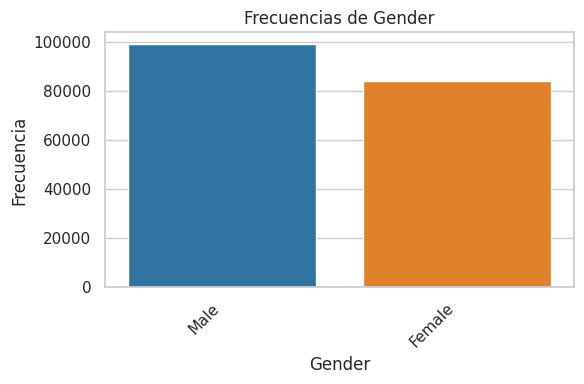


Columna: Vehicle_Age
Vehicle_Age
1-2 Year     95922
< 1 Year     79231
> 2 Years     7779
Name: count, dtype: int64
--> Categorías con frecuencia <20: 0
--> Categorías con frecuencia <10: 0
------------------------------------------------------------


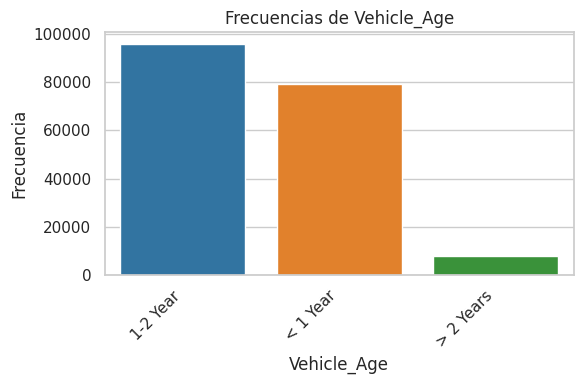


Columna: Vehicle_Damage
Vehicle_Damage
Yes    92455
No     90477
Name: count, dtype: int64
--> Categorías con frecuencia <20: 0
--> Categorías con frecuencia <10: 0
------------------------------------------------------------


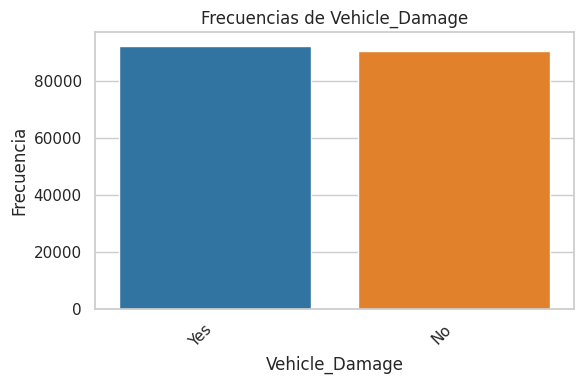


=== Columnas numéricas (int/float) ===

Columna: Age
   Min: 20.00 | Max: 85.00
   Media: 38.80 | Mediana: 36.00
   Valores únicos: 66
------------------------------------------------------------
Columna: Driving_License
   Min: 0.00 | Max: 1.00
   Media: 1.00 | Mediana: 1.00
   Valores únicos: 2
------------------------------------------------------------
Columna: Region_Code
   Min: 0.00 | Max: 52.00
   Media: 26.37 | Mediana: 28.00
   Valores únicos: 53
------------------------------------------------------------
Columna: Previously_Insured
   Min: 0.00 | Max: 1.00
   Media: 0.46 | Mediana: 0.00
   Valores únicos: 2
------------------------------------------------------------
Columna: Annual_Premium
   Min: 2630.00 | Max: 540165.00
   Media: 30566.36 | Mediana: 31690.00
   Valores únicos: 40628
------------------------------------------------------------
Columna: Policy_Sales_Channel
   Min: 1.00 | Max: 163.00
   Media: 112.15 | Mediana: 135.00
   Valores únicos: 148
--------------

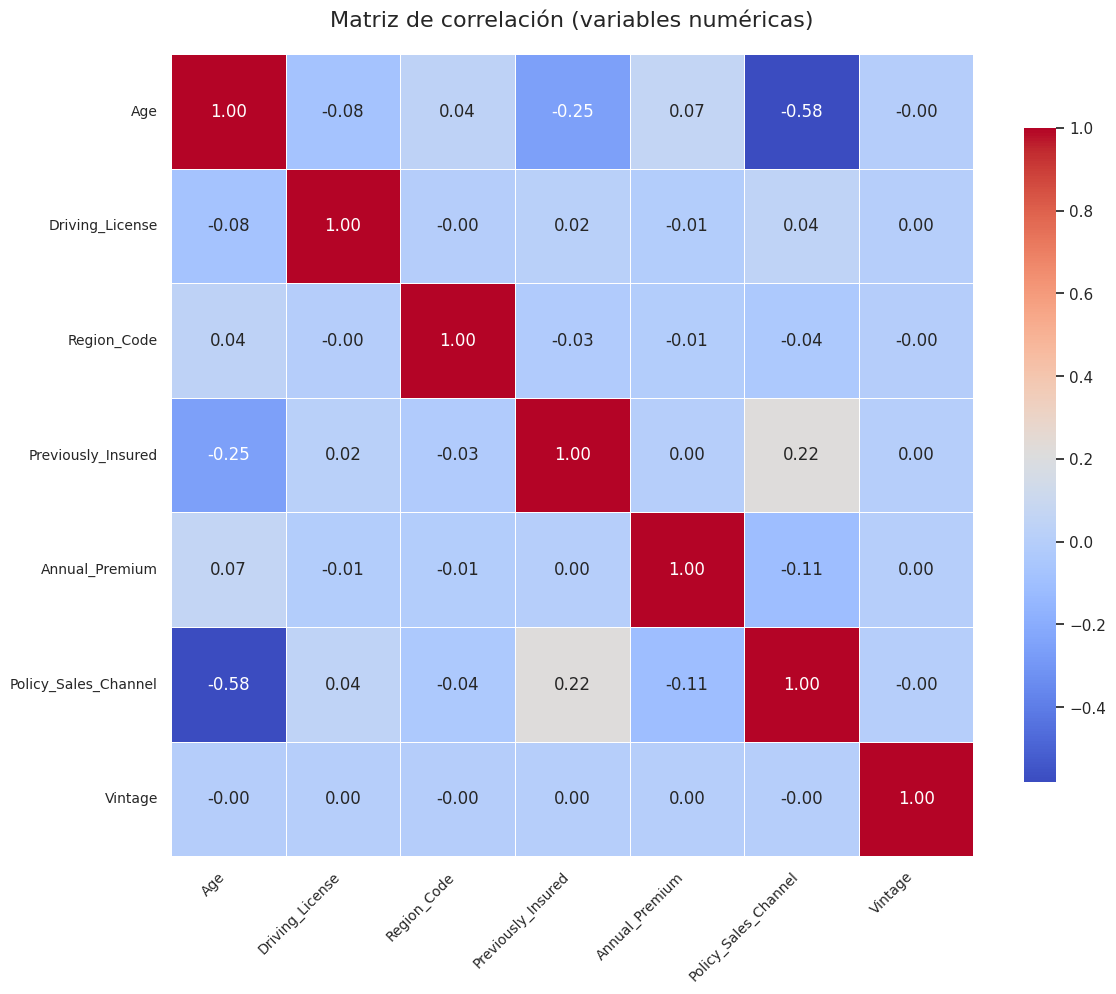


=== Distribuciones de columnas numéricas ===


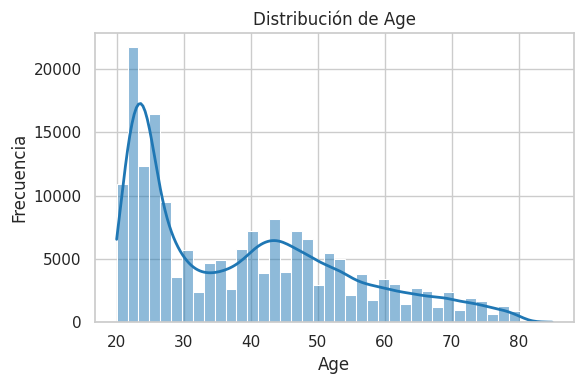

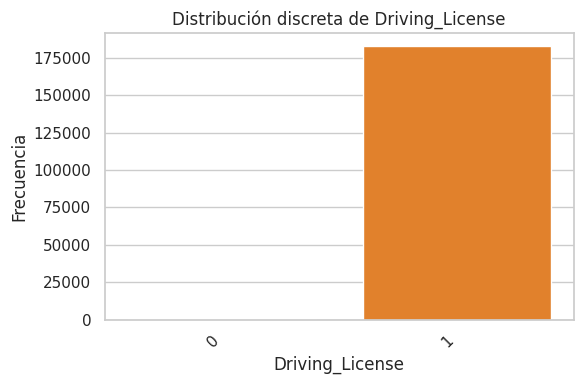

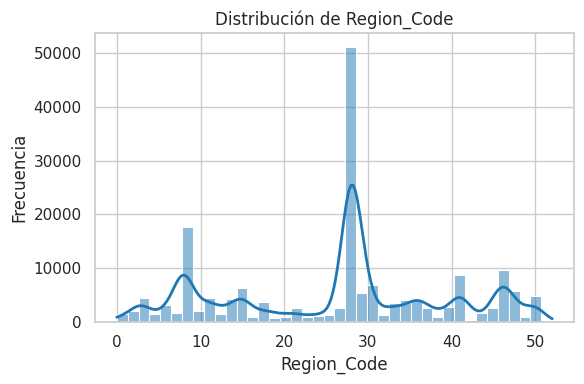

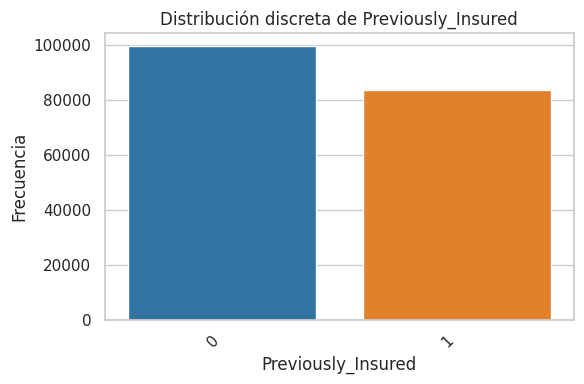

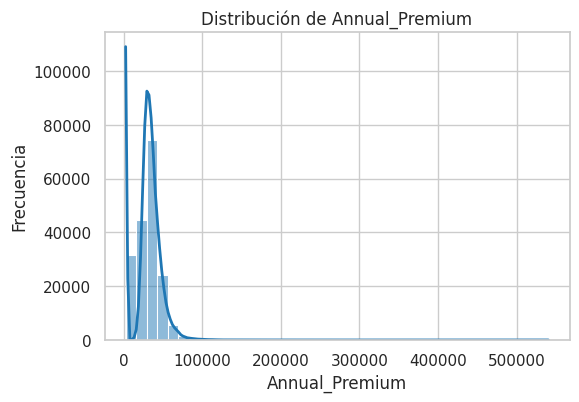

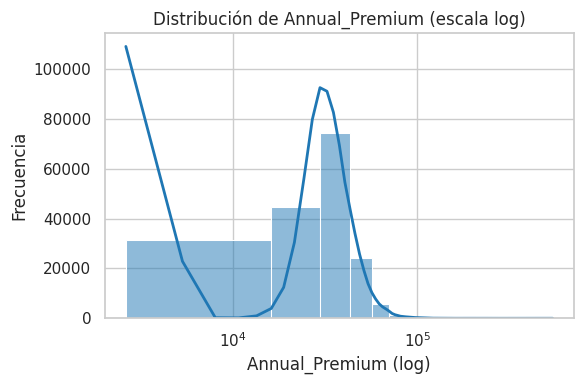

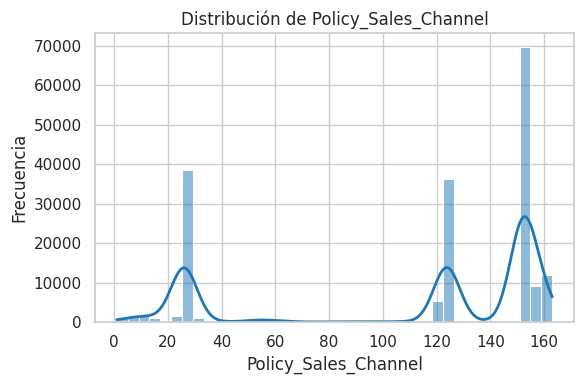

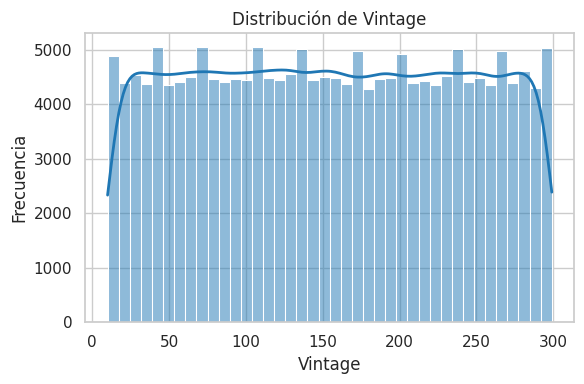


===== FIN DE RESUMEN =====


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Silenciamos SOLO el warning concreto de use_inf_as_na
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*use_inf_as_na.*"
)


def visualize_data(df, target_col=None, max_cat_levels=20, sample_for_pairs=3000):
    """
    Visualiza un DataFrame:
    - Número de filas y columnas
    - Columnas categóricas y sus frecuencias (y barras si tienen pocas categorías)
    - Cuántas categorías tienen baja frecuencia (<20 y <10)
    - Columnas numéricas con rango, nulos y número de valores únicos
    - Matriz de correlación numérica
    - Histogramas / barplots de columnas numéricas
    - (Opcional) Distribución de la variable objetivo
    - (Opcional) Boxplots de numéricas vs target
    """

    print("===== INFORMACIÓN GENERAL =====")
    print(f"Número de columnas: {len(df.columns)}")
    print(f"Número de filas: {len(df)}\n")

    # --- Distribución de la variable objetivo (si existe) ---
    if target_col is not None and target_col in df.columns:
        print("=== Distribución de la variable objetivo ===\n")
        vc_target = df[target_col].value_counts()
        total = len(df)
        for cls, cnt in vc_target.items():
            print(f"Clase {cls}: {cnt} ({cnt/total:.2%})")

        plt.figure(figsize=(5, 4))
        sns.barplot(x=vc_target.index.astype(str), y=vc_target.values)
        plt.title(f"Distribución de clases ({target_col})")
        plt.xlabel(target_col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

    # --- Columnas categóricas ---
    print("\n=== Columnas de tipo object (strings/objetos) ===\n")
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    if len(cat_cols) == 0:
        print("No hay columnas categóricas.\n")
    else:
        for col in cat_cols:
            print(f"\nColumna: {col}")
            vc = df[col].value_counts(dropna=False)
            print(vc)
            under_20 = (vc < 20).sum()
            under_10 = (vc < 10).sum()
            print(f"--> Categorías con frecuencia <20: {under_20}")
            print(f"--> Categorías con frecuencia <10: {under_10}")
            print("-" * 60)

            # Gráfico de barras para categorías
            plt.figure(figsize=(6, 4))
            if len(vc) <= max_cat_levels:
                # Todas las categorías
                sns.barplot(x=vc.index.astype(str), y=vc.values)
                plt.title(f"Frecuencias de {col}")
                plt.xticks(rotation=45, ha="right")
            else:
                # Top 10 + "Otros"
                top_k = 10
                vc_top = vc.head(top_k)
                others = vc[top_k:].sum()
                vc_plot = vc_top.append(pd.Series({"Others": others}))
                sns.barplot(x=vc_plot.index.astype(str), y=vc_plot.values)
                plt.title(f"Frecuencias de {col} (Top {top_k} + Others)")
                plt.xticks(rotation=45, ha="right")

            plt.ylabel("Frecuencia")
            plt.tight_layout()
            plt.show()

    # --- Columnas numéricas ---
    print("\n=== Columnas numéricas (int/float) ===\n")
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    
    # Quitamos columnas que no deben visualizarse
    to_exclude = {"id", "ID", "Id"}  # por si cambia el nombre
    num_cols = [c for c in num_cols if c not in to_exclude]

    for col in num_cols:
        col_min = df[col].min()
        col_max = df[col].max()
        col_mean = df[col].mean()
        col_median = df[col].median()
        n_unique = df[col].nunique()
        n_null = df[col].isnull().sum()

        print(f"Columna: {col}")
        print(f"   Min: {col_min:.2f} | Max: {col_max:.2f}")
        print(f"   Media: {col_mean:.2f} | Mediana: {col_median:.2f}")
        print(f"   Valores únicos: {n_unique}")
        if n_null > 0:
            print(f"   Valores nulos: {n_null}")
        print("-" * 60)

    # --- Valores nulos ---
    print("\n=== Valores nulos por columna ===")
    print(df.isnull().sum())

    # --- Matriz de correlación ---
    print("\n=== Matriz de Correlación ===")
    if len(num_cols) > 1:
        corr = df[num_cols].corr(numeric_only=True)

        # Tamaño dinámico pero más grande y cómodo
        fig_width = max(12, 1 + 0.6 * len(num_cols))
        fig_height = max(10, 1 + 0.6 * len(num_cols))

        plt.figure(figsize=(fig_width, fig_height))

        # Si hay muchas columnas, quitamos anotaciones para que no sea ilegible
        annot_flag = len(num_cols) <= 20

        sns.heatmap(
            corr,
            annot=annot_flag,
            fmt=".2f",
            cmap="coolwarm",
            square=True,
            linewidths=0.6,
            cbar_kws={"shrink": 0.8}
        )

        plt.title("Matriz de correlación (variables numéricas)", fontsize=16, pad=20)
        plt.xticks(rotation=45, ha="right", fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()

    else:
        print("No hay suficientes columnas numéricas para calcular correlación.\n")


    # --- Histogramas / barplots numéricos ---
    print("\n=== Distribuciones de columnas numéricas ===")
    
    # Sustituimos inf y -inf por NaN para evitar warnings
    df_numeric = df[num_cols].replace([np.inf, -np.inf], np.nan)

    for col in num_cols:
        series = df_numeric[col].dropna()
        plt.figure(figsize=(6, 4))

        n_unique = df[col].nunique()

        if n_unique <= 20:
            # Variable numérica discreta (pocas categorías) → barplot
            vc = df_numeric[col].dropna().value_counts().sort_index()
            sns.barplot(x=vc.index.astype(str), y=vc.values)
            plt.title(f"Distribución discreta de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=45, ha="right")
        else:
            # Variable continua → histograma + KDE
            sns.histplot(df_numeric[col].dropna(), bins=40, kde=True)
            plt.title(f"Distribución de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")

        
            # Si está muy sesgada (por ejemplo Annual_Premium), mostramos escala log
            if series.skew() > 1.0:
                plt.figure(figsize=(6, 4))
                sns.histplot(series, bins=40, kde=True)
                plt.xscale("log")
                plt.title(f"Distribución de {col} (escala log)")
                plt.xlabel(col + " (log)")
                plt.ylabel("Frecuencia")
                plt.tight_layout()
                plt.show()
                continue

        plt.tight_layout()
        plt.show()

    # --- Boxplots numéricas vs target (si existe y es binaria) ---
    if target_col is not None and target_col in df.columns:
        if df[target_col].nunique() == 2:
            print("\n=== Boxplots de columnas numéricas por clase objetivo ===")
            for col in num_cols:
                if col == target_col:
                    continue
                plt.figure(figsize=(6, 4))
                sns.boxplot(data=df, x=target_col, y=col)
                plt.title(f"{col} por {target_col}")
                plt.xlabel(target_col)
                plt.ylabel(col)
                plt.tight_layout()
                plt.show()
        else:
            print(f"\nLa columna {target_col} no es binaria, se omiten boxplots por clase.")

    print("\n===== FIN DE RESUMEN =====")

# NO incluye la columna Response, el desbalance lo vemos posteriormente
visualize_data(X_train_df)


# Desequilibrio de las clases

Aqui usamos train entero simplemente para ver como de desbalanceado esta el problema. 


=== Distribución de la variable objetivo ===
Clase 0: 267573 (87.76%)
Clase 1: 37314 (12.24%)


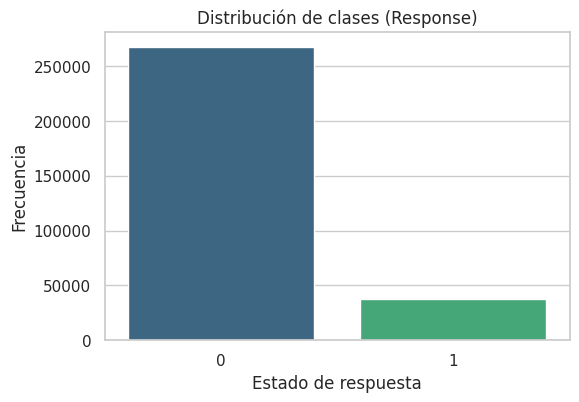

In [8]:
def check_class_balance(df, target_col="Response"):
    print("\n=== Distribución de la variable objetivo ===")
    counts = df[target_col].value_counts()
    total = len(df)
    for k, v in counts.items():
        print(f"Clase {k}: {v} ({v/total:.2%})")

    plt.figure(figsize=(6, 4))
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.title("Distribución de clases (Response)")
    plt.xlabel("Estado de respuesta")
    plt.ylabel("Frecuencia")
    plt.show()
    
check_class_balance(train)

# Conclusiones de los datos vistos

## Variables categóricas

### Gender

- Male ≈ 54%, Female ≈ 46%, bien balanceado.

Es un predictor débil por sí solo, pero puede interactuar con edad, zona, etc.

### Vehicle_Age

- 1–2 Year es la categoría dominante (≈ 48%).
- < 1 Year también tiene alta frecuencia.
- 2 Years es muy pequeña (~4%).

Esto sugiere que la mayoría de clientes tienen coches relativamente nuevos, lo cual puede correlacionarse con probabilidad de contratar seguro.

### Vehicle_Damage

- Yes ≈ No (50/50).

Balanceada, muy útil como predictor porque diferencia clientes con historial reciente de daño.


## Variables numéricas

### Age

- Rango 20–85.
- Media ≈ 38.8, Mediana ≈ 36 - distribución levemente sesgada a la derecha.

Suficiente variabilidad, buen predictor.

### Driving_License

- Variable binaria mucho más cerca del “1” - casi todos tienen licencia.

Poco útil para predicción por baja variabilidad. La variable Driving_License está prácticamente constante: más del 99% de las observaciones tienen valor 1, aunque la mantenemos por si interactúa con otras variables.

### Region_Code

- 53 regiones distintas - alta cardinalidad.

Importante: esto puede perjudicar a One-Hot Encoding completo, mejor hacer frecuency encoding
### Previously_Insured

- Binaria (0/1).
- Media 0.46 - dataset equilibrado.
- 
Suele ser uno de los predictores más fuertes (quien ya estaba asegurado se comporta distinto).

### Annual_Premium

- Rango extremadamente amplio: 2,630 → 540,165.
- Media ≈ 30k, Mediana ≈ 31k.

Annual_Premium muestra una distribución fuertemente sesgada a la derecha, con algunos valores extremadamente altos. En escala normal la masa está concentrada entre ~20k y ~90k, pero en escala log se aprecia mejor la estructura. Este comportamiento justifica capar o transformar la variable en el preprocesado.

### Policy_Sales_Channel

- 148 valores únicos - muy alta cardinalidad.
- Representa distintos canales comerciales - puede tener fuerte correlación con la decisión final.
- No conviene One-Hot completo. Mejor agrupar canales raros o usar encoding ordinal basado en frecuencia.

### Vintage

- Rango 10–299, relativamente uniforme.
- Representa cuántos días lleva el cliente con la aseguradora.
- Buena variable explicativa.

# Limpieza de datos

En la limpieza divido las columnas según su naturaleza: `las numéricas` (Age, Annual_Premium, Vintage y las binarias 0/1 como Driving_License y Previously_Insured) se imputan con la mediana y se les aplica un recorte de outliers entre los percentiles 1% y 99%, lo que reduce el impacto de valores extremos (especialmente en Annual_Premium) sin cambiar demasiado la estructura general de los datos. Las variables `categóricas binarias` (Gender, Vehicle_Damage) se codifican con One-Hot Encoder con drop="if_binary" para obtener una única dummy por variable, mientras que Vehicle_Age, que es  `ordinal`, se codifica con un OrdinalEncoder respetando el orden natural < 1 Year < 1–2 Year < > 2 Years. Finalmente, las variables `categóricas de alta cardinalidad` (Region_Code y Policy_Sales_Channel) se transforman mediante Frequency Encoding, sustituyendo cada categoría por su frecuencia relativa en el train; esto evita crear miles de columnas con One-Hot y sigue capturando información útil sobre qué regiones/canales son más frecuentes. La columna id se descarta porque solo actúa como índice y no aporta información predictiva.


Se utiliza la mediana para imputar valores numéricos porque es un estimador mucho más robusto que la media cuando las variables presentan outliers o distribuciones muy sesgadas, como ocurre en este dataset, especialmente en Annual_Premium. La media se desplaza con valores extremos y puede introducir imputaciones poco representativas, mientras que la mediana refleja mejor el valor típico de la variable. Esto evita distorsiones en los splits de los modelos basados en árboles y genera un preprocesado más estable y realista.

In [25]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#  Transformadores personalizados
class ClippingTransformer(BaseEstimator, TransformerMixin):
    """
    Recorta (clipa) outliers numéricos columna a columna entre dos cuantiles.
    Por defecto: [1%, 99%].
    """
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X_arr = np.asarray(X, dtype=float)
        self.lower_ = np.quantile(X_arr, self.lower_q, axis=0)
        self.upper_ = np.quantile(X_arr, self.upper_q, axis=0)
        return self

    def transform(self, X):
        X_arr = np.asarray(X, dtype=float)
        X_clipped = np.clip(X_arr, self.lower_, self.upper_)
        return X_clipped

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    Codifica columnas categóricas de alta cardinalidad por frecuencia:
    cada categoría se sustituye por su frecuencia relativa en train.
    """
    def __init__(self):
        self.maps_ = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            freq = X_df[col].value_counts(normalize=True)
            self.maps_[col] = freq
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for i, col in enumerate(X_df.columns):
            freq_map = self.maps_[col]
            X_df.iloc[:, i] = X_df.iloc[:, i].map(freq_map).fillna(0.0)
        return X_df.values
        
    def get_feature_names_out(self, input_features=None):
        # Igual: devolvemos los mismos nombres que entran
        return np.asarray(input_features)

#  Definición de columnas por tipo

numeric_cols = [
    "Age",
    "Driving_License",      # binarias, pero ya en 0/1 → las tratamos como numéricas
    "Previously_Insured",
    "Annual_Premium",
    "Vintage"
]

binary_cols = ["Gender", "Vehicle_Damage"]          # categóricas binarias
ordinal_cols = ["Vehicle_Age"]                      # categórica ordinal
high_card_cols = ["Region_Code", "Policy_Sales_Channel"]  # alta cardinalidad
drop_cols = ["id"]                                  # se elimina

# Pipelines por tipo de columna

# Numéricas: imputación + capado de outliers
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", ClippingTransformer(lower_q=0.01, upper_q=0.99)),
])

# Binarias categóricas: imputación + One-Hot (drop if binary)
binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        drop="if_binary",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Ordinal: imputación + OrdinalEncoder con orden explícito
ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[
        ["< 1 Year", "1-2 Year", "> 2 Years"]
    ]))
])

# 3.4 Alta cardinalidad: imputación + Frequency Encoding
high_card_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("freq_enc", FrequencyEncoder())
])

# ColumnTransformer + Pipeline final

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("bin", binary_pipeline, binary_cols),
        ("ord", ordinal_pipeline, ordinal_cols),
        ("high_card", high_card_pipeline, high_card_cols),
    ],
    remainder="drop"   # elimina 'id' y cualquier columna no especificada
)

cleaning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])


# Aplicar el pipeline a nuestros datos de manera segura

Importante evitar el data leakage. Volvemos a separar solo para reiniciar datos (no se estan separando de otra manera por el random state), asi evitamos cualquier error, por si la visualización manipula los datos

In [26]:
from sklearn.model_selection import train_test_split 


# Separamos los features y el target:
target = "Response"

X = train.drop(columns=[target])
y = train[target].values

# Split estratificado en train i validation:
X_train_df, X_valid_df, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

print("Tamaños -> Train:", X_train_df.shape, " Valid:", X_valid_df.shape)


# Aplicamos el cleaning_pipline (solo hacemos el fit con train, para evitar dataleakage)
cleaning_pipeline.fit(X_train_df)

X_train_clean = cleaning_pipeline.transform(X_train_df)
X_valid_clean = cleaning_pipeline.transform(X_valid_df)
X_test_clean  = cleaning_pipeline.transform(test)

print("Dimensiones después del preprocesado:")
print("Train:", X_train_clean.shape)
print("Valid:", X_valid_clean.shape)
print("Test:", X_test_clean.shape)

# Ahora ya podemos entrenar los modelos sobre datos limpios

Tamaños -> Train: (182932, 11)  Valid: (121955, 11)
Dimensiones después del preprocesado:
Train: (182932, 10)
Valid: (121955, 10)
Test: (76222, 10)


# Visualizar datos limpios

Ver como queda el dataframe nuevo (asegurar que ha salido bien el proceso)

In [27]:
# Ajustamos el pipeline con train
cleaning_pipeline.fit(X_train_df)

# Transformamos
X_train_clean = cleaning_pipeline.transform(X_train_df)

# Sacamos los nombres de columnas del preprocessor
feature_names = cleaning_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Creamos DataFrame con nombres
import pandas as pd
X_train_clean_df = pd.DataFrame(X_train_clean, columns=feature_names)

# Y por fin:
X_train_clean_df.head()


,num__Age,num__Driving_License,num__Previously_Insured,num__Annual_Premium,num__Vintage,bin__Gender_Male,bin__Vehicle_Damage_Yes,ord__Vehicle_Age,high_card__Region_Code,high_card__Policy_Sales_Channel
0,35.0,1.0,0.0,54832.0,191.0,0.0,1.0,1.0,0.279902,0.194690
1,25.0,1.0,0.0,31853.0,121.0,0.0,1.0,0.0,0.010955,0.353847
2,24.0,1.0,1.0,39331.0,113.0,0.0,0.0,0.0,0.052391,0.353847
3,41.0,1.0,1.0,44663.0,291.0,0.0,0.0,1.0,0.279902,0.194690
4,31.0,1.0,1.0,30435.0,95.0,1.0,0.0,0.0,0.279902,0.353847


# Entrenamiento de modelos

Buscar los mejores parametros para cada modelo con un grid search.

El codigo para entrenar los modelos estan divididos en 2. Una parte para buscar los mejores parametros, que hemos ejecutado nosotros para ver que utilizar y otra parte para usar estos parametros, que seria la actual para ahorrar tiempo. Buscar los mejores parametros tarda mucho, asi que no hace falta ejecutarlo todo el rato, con una vez basta.


In [28]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = "roc_auc"   # Usamos roc auc como metrica 


## BoostingClassifier casero
Como no es de sklearn hay que buscar parametros de forma manual.


Es importante no probar valores altos de `max_depth_values` para el weak tree. Queremos seguir la filosofia del boosting:

Aunque aumentar la profundidad del árbol a 4 o 5 puede mejorar ligeramente el AUC en validación, esto hace que el modelo deje de ser un weak learner, acercándose a un árbol complejo capaz de sobreajustar. En boosting, la filosofía es combinar muchos modelos muy simples; usar árboles demasiado profundos rompe este principio y puede producir un modelo menos estable y más sensible al ruido. Por eso se mantiene una profundidad baja (2 o 3) incluso si depths mayores parecen mejorar resultados puntuales.

parametros obtenidos al ejecutar el grid search

``` ls

Mejores params Boosting casero: {'weight_scheme': 'sqrt_inverse', 'pos_factor': None, 'num_trees': 60, 'shrinkage': 0.1, 'max_depth': 3, 'subsample_frac': 1.0, 'weight_clip': 100.0}
Mejor roc_auc valid Boosting casero: 0.8470351609638304
``` 

In [35]:
from sklearn.metrics import roc_auc_score

run_search = False   # <<--- CAMBIA A True si quieres ejecutar el grid otra vez

weight_schemes = [
    ("inverse_freq", None),
    ("sqrt_inverse", None),
    ("pos_factor", 1.5),
    ("pos_factor", 2.0),
]

M_values = [10, 20, 40, 60]
shrinkage_values = [0.02, 0.05, 0.1]
max_depth_values = [2, 3]  # NO PONER MAS DE 3!
subsample_values = [1.0, 0.8]
weight_clip_value = 100.0

best_params_bc = None
best_score_bc = -np.inf
best_bc_model = None



# Modo grid search para buscar mejores parametros
if run_search:

    for scheme, pos_factor in weight_schemes:
        # pesos iniciales
        if scheme == "pos_factor":
            initial_weights = balance_weights(y_train, scheme=scheme, pos_factor=pos_factor)
        else:
            initial_weights = balance_weights(y_train, scheme=scheme)

        for M in M_values:
            for lr in shrinkage_values:
                for depth in max_depth_values:
                    for subs in subsample_values:

                        bc = BoostingClassifier(
                            X_train_clean,
                            y_train,
                            initial_weights,
                            max_depth=depth,
                            subsample_frac=subs,
                            weight_clip=weight_clip_value
                        )

                        bc.fit(num_trees=M, shrinkage=lr)
                        valid_proba = bc.predict(X_valid_clean)
                        auc = roc_auc_score(y_valid, valid_proba)

                        if auc > best_score_bc:
                            best_score_bc = auc
                            best_params_bc = {
                                "weight_scheme": scheme,
                                "pos_factor": pos_factor,
                                "num_trees": M,
                                "shrinkage": lr,
                                "max_depth": depth,
                                "subsample_frac": subs,
                                "weight_clip": weight_clip_value,
                            }
                            best_bc_model = bc

    print("Mejores params Boosting casero:", best_params_bc)
    print("Mejor roc_auc valid Boosting casero:", best_score_bc)


# modo crear modelo con unos parametros fijos (los mejores encontrados previamente)
else:
    print("Saltando la búsqueda. Usando parámetros óptimos encontrados previamente.\n")

    """
        best_params_bc = {
        "weight_scheme": "pos_factor",
        "pos_factor": 1.5,
        "num_trees": 60,
        "shrinkage": 0.1,
        "max_depth": 3,
        "subsample_frac": 1.0,
        "weight_clip": 100.0
    }
    """
    best_params_bc = {
        "weight_scheme": "sqrt_inverse",
        "pos_factor": None,
        "num_trees": 60,
        "shrinkage": 0.1,
        "max_depth": 3,
        "subsample_frac": 1.0,
        "weight_clip": 100.0
    }

    # Generamos pesos iniciales según el esquema óptimo
    initial_weights = balance_weights(
        y_train,
        scheme=best_params_bc["weight_scheme"],
        pos_factor=best_params_bc["pos_factor"]
    )

    # Modelo final
    bc = BoostingClassifier(
        X_train_clean,
        y_train,
        initial_weights,
        max_depth=best_params_bc["max_depth"],
        subsample_frac=best_params_bc["subsample_frac"],
        weight_clip=best_params_bc["weight_clip"]
    )

    bc.fit(
        num_trees=best_params_bc["num_trees"],
        shrinkage=best_params_bc["shrinkage"]
    )

    best_bc_model = bc  # mantenemos el nombre por consistencia

    print("Modelo Boosting final creado con los mejores parámetros:\n", best_params_bc)


# calcular predicciones
prediction_train = best_bc_model.predict(X_train_clean)
prediction_validation = best_bc_model.predict(X_valid_clean)

auc_tmp = roc_auc_score(y_valid, prediction_validation)
print("Mejor roc_auc VALID (boosting) usando estos parámetros en validation:", auc_tmp)


Saltando la búsqueda. Usando parámetros óptimos encontrados previamente.

Modelo Boosting final creado con los mejores parámetros:
 {'weight_scheme': 'sqrt_inverse', 'pos_factor': None, 'num_trees': 60, 'shrinkage': 0.1, 'max_depth': 3, 'subsample_frac': 1.0, 'weight_clip': 100.0}
Mejor roc_auc VALID (boosting) usando estos parámetros en validation: 0.8470351609638304


## BaggingClassifier + DecisionTree

parametros obtenidos con el grid search

```ls

Mejores params Bagging: {'clf__estimator__max_depth': 4, 'clf__max_samples': 0.6, 'clf__n_estimators': 100}
Mejor roc_auc CV Bagging: 0.837032816722717

```

In [36]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

run_search = False   # <<< cambiar a True si quieres ejecutar búsqueda

#  Definición del pipeline
bagging_pipe = Pipeline(steps=[
    ("preprocess", cleaning_pipeline),
    ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            random_state=0,
            class_weight="balanced"
        ),
        random_state=0,
        n_jobs=-1
    ))
])

param_grid_bag = {
    "clf__n_estimators": [50, 100],
    "clf__max_samples": [0.6, 1.0],
    "clf__estimator__max_depth": [2, 4],
}

# Modo grid search para buscar mejores parametros
if run_search:

    bagging_search = GridSearchCV(
        estimator=bagging_pipe,
        param_grid=param_grid_bag,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    bagging_search.fit(X_train_df, y_train)

    print("Mejores params Bagging:", bagging_search.best_params_)
    print("Mejor roc_auc CV Bagging:", bagging_search.best_score_)

    best_bagging = bagging_search.best_estimator_


# modo crear modelo con unos parametros fijos (los mejores encontrados previamente)
else:
    print("Saltando búsqueda. Usando los mejores parámetros encontrados previamente.\n")

    best_params_bag = {
        "clf__estimator__max_depth": 4,
        "clf__max_samples": 0.6,
        "clf__n_estimators": 100
    }

    best_bagging = Pipeline(steps=[
        ("preprocess", cleaning_pipeline),
        ("clf", BaggingClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=best_params_bag["clf__estimator__max_depth"],
                random_state=0,
                class_weight="balanced"
            ),
            n_estimators=best_params_bag["clf__n_estimators"],
            max_samples=best_params_bag["clf__max_samples"],
            random_state=0,
            n_jobs=-1
        ))
    ])

    # Entrenamos el modelo final
    best_bagging.fit(X_train_df, y_train)


# calcular predicciones
bag_train_proba = best_bagging.predict_proba(X_train_df)[:, 1]
bag_valid_proba = best_bagging.predict_proba(X_valid_df)[:, 1]


auc_tmp = roc_auc_score(y_valid, bag_valid_proba)
print("Mejor roc_auc VALID (bagging) usando estos parámetros en validation:", auc_tmp)


Saltando búsqueda. Usando los mejores parámetros encontrados previamente.

Mejor roc_auc VALID (bagging) usando estos parámetros en validation: 0.837032816722717


## RandomForestClassifier

Resultado obtenido del grid search
```ls
Mejores params RF: {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
Mejor roc_auc CV RF: 0.8519083153388946

```

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

run_search = False   # <<< pon True si quieres volver a lanzar el grid

#  Definición del pipeline
rf_pipe = Pipeline(steps=[
    ("preprocess", cleaning_pipeline),
    ("clf", RandomForestClassifier(
        random_state=0,
        n_jobs=-1,
        class_weight="balanced"      # ← FORZAMOS BALANCED
    ))
])

param_grid_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 6],
    "clf__min_samples_leaf": [1, 10],
}

# Modo grid search para buscar mejores parametros
if run_search:

    rf_search = GridSearchCV(
        estimator=rf_pipe,
        param_grid=param_grid_rf,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    rf_search.fit(X_train_df, y_train)

    print("Mejores params RF:", rf_search.best_params_)
    print("Mejor roc_auc CV RF:", rf_search.best_score_)

    best_rf = rf_search.best_estimator_


# modo crear modelo con unos parametros fijos (los mejores encontrados previamente)
else:
    print("Saltando búsqueda. Usando los mejores parámetros de RF encontrados previamente.\n")

    best_params_rf = {
        "clf__max_depth": None,
        "clf__min_samples_leaf": 10,
        "clf__n_estimators": 200
    }

    best_rf = Pipeline(steps=[
        ("preprocess", cleaning_pipeline),
        ("clf", RandomForestClassifier(
            n_estimators=best_params_rf["clf__n_estimators"],
            max_depth=best_params_rf["clf__max_depth"],
            min_samples_leaf=best_params_rf["clf__min_samples_leaf"],
            random_state=0,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

    best_rf.fit(X_train_df, y_train)

# calcular predicciones
rf_train_proba = best_rf.predict_proba(X_train_df)[:, 1]
rf_valid_proba = best_rf.predict_proba(X_valid_df)[:, 1]

auc_tmp = roc_auc_score(y_valid, rf_valid_proba)
print("Mejor roc_auc VALID (RF) usando estos parámetros en validation:", auc_tmp)


Saltando búsqueda. Usando los mejores parámetros de RF encontrados previamente.

Mejor roc_auc VALID (RF) usando estos parámetros en validation: 0.8519083153388946


## AdaBoostClassifier

Resultado obtenido 

``` ls

Mejores params AdaBoost: {'clf__estimator__max_depth': 2, 'clf__learning_rate': 0.2, 'clf__n_estimators': 100}
Mejor roc_auc CV AdaBoost: 0.8553502870903509

```

In [38]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

run_search = False   # <<< pon True si quieres volver a lanzar el grid

# ---------- ADABOOST ----------

#  Definición del pipeline
ada_pipe = Pipeline(steps=[
    ("preprocess", cleaning_pipeline),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            random_state=0,
            class_weight="balanced"    # ← FORZAMOS BALANCED
        ),
        random_state=0
    ))
])

param_grid_ada = {
    "clf__n_estimators": [50, 100],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__estimator__max_depth": [1, 2],
}

# Modo grid search para buscar mejores parametros
if run_search:

    ada_search = GridSearchCV(
        estimator=ada_pipe,
        param_grid=param_grid_ada,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    ada_search.fit(X_train_df, y_train)

    print("Mejores params AdaBoost:", ada_search.best_params_)
    print("Mejor roc_auc CV AdaBoost:", ada_search.best_score_)

    best_ada = ada_search.best_estimator_

# modo crear modelo con unos parametros fijos (los mejores encontrados previamente)
else:
    print("Saltando búsqueda. Usando los mejores parámetros de AdaBoost encontrados previamente.\n")

    best_params_ada = {
        "clf__estimator__max_depth": 2,
        "clf__learning_rate": 0.2,
        "clf__n_estimators": 100
    }

    print("Parámetros usados (AdaBoost):", best_params_ada)

    best_ada = Pipeline(steps=[
        ("preprocess", cleaning_pipeline),
        ("clf", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=best_params_ada["clf__estimator__max_depth"],
                random_state=0,
                class_weight="balanced"
            ),
            n_estimators=best_params_ada["clf__n_estimators"],
            learning_rate=best_params_ada["clf__learning_rate"],
            random_state=0
        ))
    ])

    best_ada.fit(X_train_df, y_train)

# calcular predicciones
ada_train_proba = best_ada.predict_proba(X_train_df)[:, 1]
ada_valid_proba = best_ada.predict_proba(X_valid_df)[:, 1]

auc_tmp = roc_auc_score(y_valid, ada_valid_proba)
print("Mejor roc_auc VALID (AdaBoost) usando estos parámetros en validation:", auc_tmp)


Saltando búsqueda. Usando los mejores parámetros de AdaBoost encontrados previamente.

Parámetros usados (AdaBoost): {'clf__estimator__max_depth': 2, 'clf__learning_rate': 0.2, 'clf__n_estimators': 100}
Mejor roc_auc VALID (AdaBoost) usando estos parámetros en validation: 0.8553502870903509


# Código para evaluar los modelos

Calculamos las metricas de cada modelo, sus confusion matrix y las curvas de roc auc y recision-Recall (PR)

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


## Funciones de metricas

Conseguir estadisticos de los diferentes modelos : Auc roc, Auc PR, accuracy, F1, precision, recall...

In [40]:
def evaluate_model(y_true, y_proba, threshold=0.5):
    """
    y_proba: probabilidades de la clase positiva (1)
    threshold: umbral para pasar de proba -> clase
    """
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        # métricas basadas en probabilidad
        "AUC ROC": roc_auc_score(y_true, y_proba),
        "Average Precision (AUC-PR)": average_precision_score(y_true, y_proba),

        # métricas binarias estándar
        "Accuracy": accuracy_score(y_true, y_pred),

        # binary (clase positiva = 1)
        "F1 (binary)": f1_score(y_true, y_pred, zero_division=0),
        "Precision (binary)": precision_score(y_true, y_pred, zero_division=0),
        "Recall (binary)": recall_score(y_true, y_pred, zero_division=0),

        # macro
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),

        # weighted
        "F1 (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Precision (weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    return metrics


def get_confusion_matrix(y_true, y_proba, threshold=0.5):
    """
    Devuelve la matriz de confusión usando un umbral dado.
    """
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return cm


## Función para dibujar matrices de confusión

In [41]:
def plot_confusion_matrix(cm, model_name="Modelo"):
    """
    Dibuja la matriz de confusión 2x2.
    """
    plt.figure()
    plt.imshow(cm)  # sin cmap explícito
    plt.title(f"Matriz de confusión - {model_name}")
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["Pred 0", "Pred 1"])
    plt.yticks(tick_marks, ["Real 0", "Real 1"])

    # escribir los valores en cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


## Funciones para las curvas ROC y PR

In [42]:
def plot_roc_curves(y_valid, valid_probas_dict):
    plt.figure()
    for name, y_proba in valid_probas_dict.items():
        fpr, tpr, _ = roc_curve(y_valid, y_proba)
        plt.plot(fpr, tpr, label=name)

    plt.plot([0, 1], [0, 1], linestyle="--")  # línea aleatoria
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC (Validación)")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_pr_curves(y_valid, valid_probas_dict):
    plt.figure()
    for name, y_proba in valid_probas_dict.items():
        precision, recall, _ = precision_recall_curve(y_valid, y_proba)
        plt.plot(recall, precision, label=name)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curvas Precision-Recall (Validación)")
    plt.legend()
    plt.grid(True)
    plt.show()


## Probabilidades de cada modelo (train / valid)

Importante usar el dataset crudo en los modelos de sklearn (el pipeline ya los procesa) y usar el limpio en nuestra clase (no tiene pipeline integrado)

In [43]:
# ----- BOOSTING (casero) -----
boosting_train_proba = bc.predict(X_train_clean)   # proba clase 1
boosting_valid_proba = bc.predict(X_valid_clean)   # proba clase 1

# ---------- BAGGING ----------
bag_train_proba = best_bagging.predict_proba(X_train_df)[:, 1]
bag_valid_proba = best_bagging.predict_proba(X_valid_df)[:, 1]


# ---------- RANDOM FOREST ----------
rf_train_proba = best_rf.predict_proba(X_train_df)[:, 1]
rf_valid_proba = best_rf.predict_proba(X_valid_df)[:, 1]


# ---------- ADABOOST ----------
ada_train_proba = best_ada.predict_proba(X_train_df)[:, 1]
ada_valid_proba = best_ada.predict_proba(X_valid_df)[:, 1]



## Métricas en tabla (train y valid)

In [44]:
# ----- Métricas con TRAIN -----
boosting_train_metrics = evaluate_model(y_train, boosting_train_proba)
bag_train_metrics      = evaluate_model(y_train, bag_train_proba)
rf_train_metrics       = evaluate_model(y_train, rf_train_proba)
ada_train_metrics      = evaluate_model(y_train, ada_train_proba)

df_train = pd.DataFrame({
    "Boosting": boosting_train_metrics,
    "Bagging": bag_train_metrics,
    "RandomForest": rf_train_metrics,
    "AdaBoost": ada_train_metrics
})

print("RESULTADOS CON TRAIN")
display(df_train)

# ----- Métricas con VALIDATION -----
boosting_valid_metrics = evaluate_model(y_valid, boosting_valid_proba)
bag_valid_metrics      = evaluate_model(y_valid, bag_valid_proba)
rf_valid_metrics       = evaluate_model(y_valid, rf_valid_proba)
ada_valid_metrics      = evaluate_model(y_valid, ada_valid_proba)

df_valid = pd.DataFrame({
    "Boosting": boosting_valid_metrics,
    "Bagging": bag_valid_metrics,
    "RandomForest": rf_valid_metrics,
    "AdaBoost": ada_valid_metrics
})

print("RESULTADOS CON VALIDATION")
display(df_valid)


RESULTADOS CON TRAIN


,Boosting,Bagging,RandomForest,AdaBoost
AUC ROC,0.845263,0.835924,0.940930,0.854221
Average Precision (AUC-PR),0.329991,0.306319,0.700743,0.361978
Accuracy,0.648952,0.659256,0.784428,0.697368
F1 (binary),0.403788,0.408723,0.520133,0.428956
Precision (binary),0.254870,0.259463,0.357445,0.278880
Recall (binary),0.971324,0.962301,0.954619,0.928756
F1 (macro),0.577515,0.584694,0.690562,0.611545
Precision (macro),0.624146,0.625507,0.674597,0.632081
Recall (macro),0.787660,0.789649,0.857657,0.796929
F1 (weighted),0.708719,0.717593,0.819275,0.749442


RESULTADOS CON VALIDATION


,Boosting,Bagging,RandomForest,AdaBoost
AUC ROC,0.847035,0.837033,0.851908,0.855350
Average Precision (AUC-PR),0.333897,0.308088,0.353244,0.361493
Accuracy,0.648403,0.659055,0.751449,0.697733
F1 (binary),0.403273,0.408484,0.448592,0.429833
Precision (binary),0.254501,0.259301,0.307896,0.279426
Recall (binary),0.970722,0.961879,0.826075,0.930926
F1 (macro),0.577027,0.584495,0.644079,0.612095
Precision (macro),0.623890,0.625378,0.638101,0.632576
Recall (macro),0.787088,0.789351,0.783559,0.798069
F1 (weighted),0.708249,0.717422,0.791715,0.749743


## Matrices de confusión 


Matriz de confusión Boosting (VALIDATION):
[[64587 42442]
 [  437 14489]]

Matriz de confusión Bagging (VALIDATION):
[[66018 41011]
 [  569 14357]]

Matriz de confusión RandomForest (VALIDATION):
[[79313 27716]
 [ 2596 12330]]

Matriz de confusión AdaBoost (VALIDATION):
[[71197 35832]
 [ 1031 13895]]


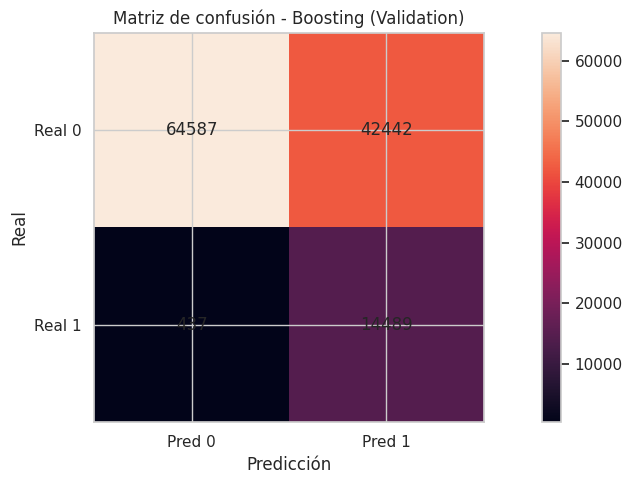

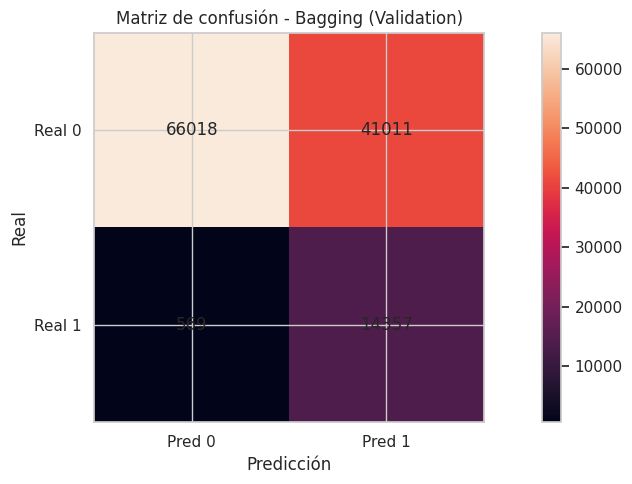

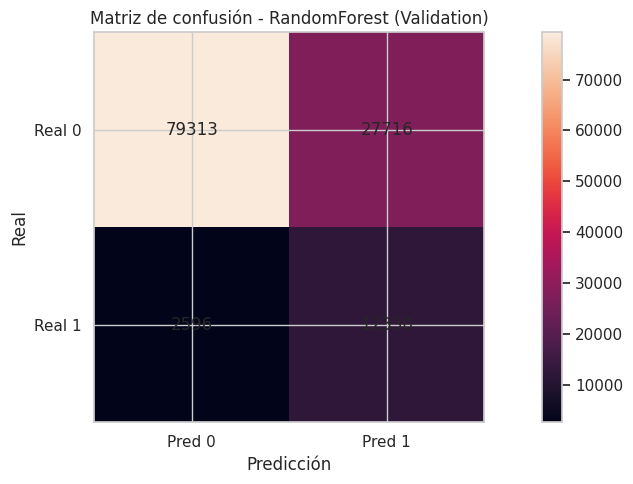

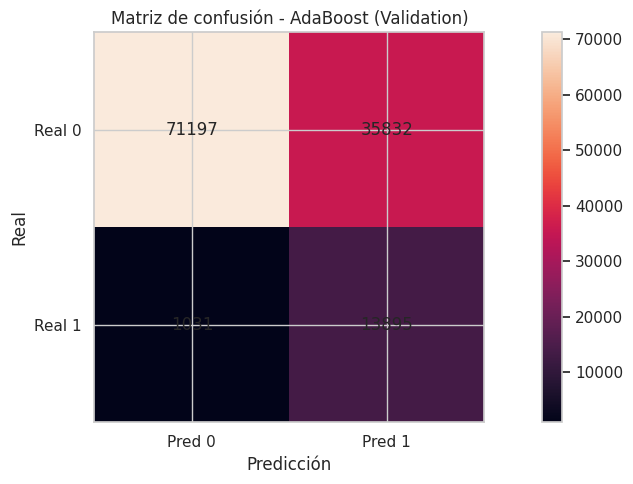

In [45]:
# ----- MATRICES DE CONFUSIÓN (VALIDATION) -----
cm_valid_boosting = get_confusion_matrix(y_valid, boosting_valid_proba)
cm_valid_bagging  = get_confusion_matrix(y_valid, bag_valid_proba)
cm_valid_rf       = get_confusion_matrix(y_valid, rf_valid_proba)
cm_valid_ada      = get_confusion_matrix(y_valid, ada_valid_proba)

print("\nMatriz de confusión Boosting (VALIDATION):")
print(cm_valid_boosting)
print("\nMatriz de confusión Bagging (VALIDATION):")
print(cm_valid_bagging)
print("\nMatriz de confusión RandomForest (VALIDATION):")
print(cm_valid_rf)
print("\nMatriz de confusión AdaBoost (VALIDATION):")
print(cm_valid_ada)

# Gráficas
plot_confusion_matrix(cm_valid_boosting, model_name="Boosting (Validation)")
plot_confusion_matrix(cm_valid_bagging,  model_name="Bagging (Validation)")
plot_confusion_matrix(cm_valid_rf,       model_name="RandomForest (Validation)")
plot_confusion_matrix(cm_valid_ada,      model_name="AdaBoost (Validation)")


## Curvas ROC y Precision-Recall

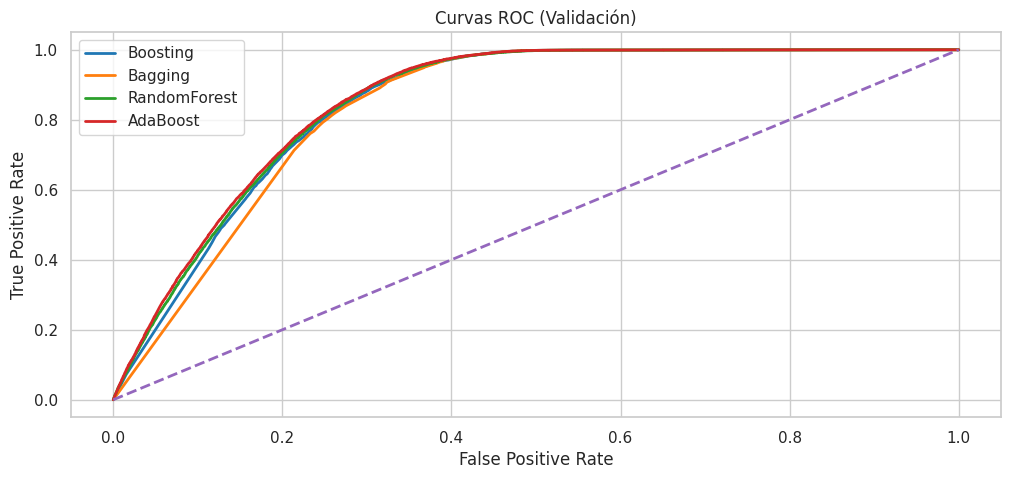

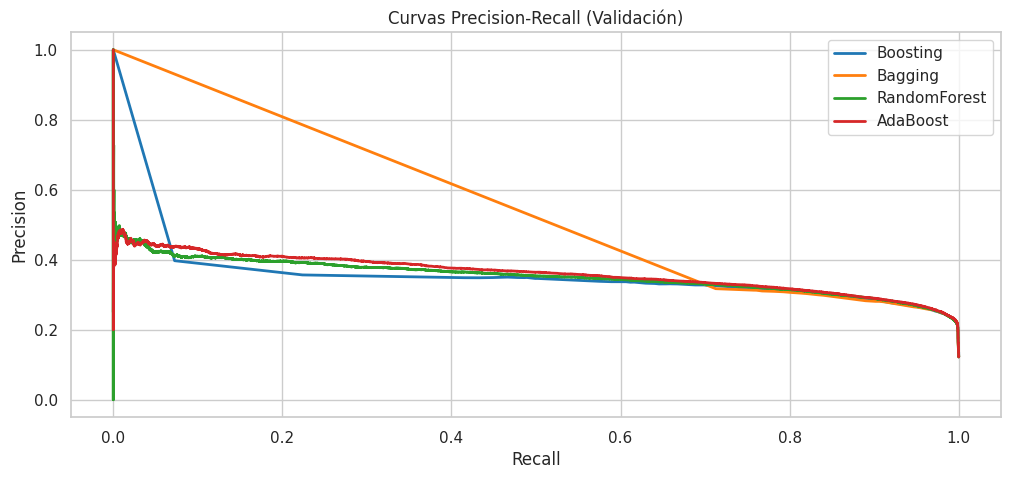

In [46]:
valid_probas = {
    "Boosting": boosting_valid_proba,
    "Bagging": bag_valid_proba,
    "RandomForest": rf_valid_proba,
    "AdaBoost": ada_valid_proba
}

plot_roc_curves(y_valid, valid_probas)
plot_pr_curves(y_valid, valid_probas)


# Resultados de nuestro modelo ( comparación con los otros en la pregunta 4 )

Nuestro modelo de boosting consigue un rendimiento muy consistente entre entrenamiento y validación, indicando que no sufre sobreajuste. Los resultados son:

```
Métrica	    Train	Validación
AUC ROC	    0.8445	0.8470
AUC-PR	    0.3299	0.3338
F1 binary   0.4037	0.4032
Accuracy    0.6489	0.6484
```

Las métricas revelan varias cosas importantes:


## Sobre el overfitting

No hay sobreajuste significativo, ya que los resultados de train y validación son prácticamente idénticos.
Esto demuestra que el modelo generaliza bien y no está memorizando patrones específicos del entrenamiento, algo especialmente relevante en boosting, donde el riesgo de sobreajuste existe si los árboles son demasiado profundos o si la actualización de pesos es demasiado agresiva.

Este buen comportamiento es coherente con los mecanismos de regularización incorporados:
-  shrinkage/learning rate : reduce la influencia de cada árbol, haciendo que el aprendizaje sea progresivo y estable.
-  árboles poco profundos (max_depth=3) : evitan que un único árbol aprenda relaciones demasiado complejas.
-  clipping de pesos : evitar que unos ejemplos dominen encima de otros
-  subsampling aleatorio : introduce diversidad entre árboles y reduce correlación entre ellos, como en Random Forest.

Gracias a estas decisiones, el boosting mantiene un equilibrio adecuado entre capacidad y estabilidad, logrando un sesgo-variancia muy favorable.

## Sobre el desbalance

El modelo obtiene un recall muy alto sobre la clase positiva (0.97), a costa de una precisión menor (0.25).
Esto está alineado con el uso de la Weighted Binary Cross Entropy, que penaliza más los errores sobre la clase minoritaria.

En un contexto como el de predicción de respuesta a un seguro, maximizar recall es preferible para no perder clientes potenciales. Además, aunque el AUC-PR pueda parecer bajo, un valor de 0.32 es muy superior al baseline aleatorio (~0.12) y comparable al rendimiento de modelos avanzados como Random Forest o AdaBoost.

La matriz de confusión confirma este comportamiento orientado al recall: muy pocos falsos negativos y un número moderado de falsos positivos, coherente con el objetivo del modelo.

## Sobre las curvas

Sobre las curvas 

### ROC

La curva ROC del boosting está entre Bagging y RF, muy próxima a AdaBoost, reflejando un modelo estable que discrimina bien entre clases. 

### Precision-Recall

Aunque queda ligeramente por debajo de RF y AdaBoost, su forma muestra claramente el efecto de maximizar recall:

- la precisión cae más rápido cuando aumenta el recall,
- pero el área total sigue siendo competitiva.


# Preguntes
Per acabar, contesteu les següents preguntes:
1. Quines mètriques heu fet servir per avaluar els models? Com depenen aquestes mètriques segons el balanç del model?
2. Prova d'inicialitzar el model amb els pesos a $1/n$. Hi ha diferència entre pesos uniformes o cambiants per classe?
3. Descriu breument l'estratègia d'actualitzar pesos, calcul d'errors, calcul de learning rate i predicció final. Investiga quines són les estratègies que utilitza el model AdaBoost i discuteix com de similars són les teves.
4. Compara els resultats del teu model amb les següents estratègies: RandomForest, Bagging i AdaBoost.



# --- Respostes Preguntes ---

## Pregunta 1

¿Qué métricas hemos utilizado para evaluar los modelos?

Para evaluar los modelos de clasificación binaria ,incluyendo nuestro Boosting personalizado y los modelos de sklearn, hemos utilizado un conjunto de métricas adecuadas para problemas con desbalance de clases, donde una clase aparece con mucha menos frecuencia que la otra.

Las métricas utilizadas han sido:

### 1. AUC ROC (Área bajo la curva ROC)

Mide la capacidad del modelo para separar correctamente las clases.
No depende de un umbral fijo y evalúa cómo de bien el modelo ordena las muestras positivas por encima de las negativas.

### 2. AUC-PR (Average Precision, área bajo la curva Precision–Recall)

Es especialmente útil en datasets desbalanceados.
Resume el compromiso entre precision y recall para todos los posibles umbrales.
Cuando la clase positiva es rara, esta métrica es mucho más informativa que AUC ROC.

### 3. Accuracy

Porcentaje de predicciones correctas.
Sin embargo, es poco fiable en escenarios desbalanceados, ya que un modelo trivial que predice siempre la clase mayoritaria puede obtener una accuracy muy alta.

### 4. Precision

De todas las predicciones positivas, qué proporción es correcta.
Sirve para saber si el modelo “se equivoca mucho” cuando decide predecir la clase minoritaria.

### 5. Recall

De todas las muestras positivas reales, cuántas detecta el modelo.
Es importante cuando es más grave dejar escapar positivos.

### 6. F1-score

Media armónica entre precision y recall.
Equilibra ambas métricas y es más robusto al desbalanceo que accuracy.

### 7. Métricas macro (macro-F1, macro-Precision, macro-Recall)

Calculan la media no ponderada entre las métricas de cada clase.
Tratan por igual a la clase minoritaria y a la mayoritaria.
Son útiles para detectar si el modelo ignora completamente la clase minoritaria.

### 8. Métricas weighted (weighted-F1, weighted-Precision, weighted-Recall)

Promedios ponderados según la frecuencia de cada clase.
Representan mejor el rendimiento global, pero pueden ocultar problemas si la clase mayoritaria domina demasiado.

### 9. Matriz de confusión

Permite ver explícitamente:

- cuántos positivos se detectan correctamente,
- cuántos se pierden,
- cuántos negativos se confunden con positivos,
- y si hay un sesgo hacia una clase.

### ¿Cómo dependen estas métricas del balanceo de las clases?

El desbalanceo afecta mucho a las métricas. En concreto:

### 1. Accuracy

Es la métrica menos fiable.
Con mucho desbalance, un modelo que predice siempre la clase mayoritaria obtiene una accuracy muy alta. Es decir modelos aleatorios o que no predicen bien tienen buen accuracy siendo una mala métrica para medir la eficiencia del modelo

### 2. Precision y Recall

Se ven muy afectados:

- Si el modelo predice muy pocos positivos - precision alta, recall bajo.
- Si el modelo predice demasiados positivos - recall alto, precision baja.

Cuando la clase minoritaria es muy pequeña, la precision suele caer rápidamente.

### 3. F1-score

Combina precision y recall, pero también se ve afectado por el desbalance.
Es sensible a cómo trata el modelo a la clase minoritaria.

### 4. Métricas macro

Dan el mismo peso a cada clase.
Por eso penalizan mucho a los modelos que ignoran la clase minoritaria.

### 5. Métricas weighted

Ajustan el peso según el tamaño de cada clase.
Dan una idea del rendimiento global, aunque pueden esconder que la clase minoritaria esté mal clasificada.

### 6. AUC ROC

Es relativamente estable frente al desbalanceo.
Mide cuán bien separa el modelo las distribuciones de probabilidades entre clases.

Pero cuando la clase positiva es muy rara, puede ser optimista.

### 7. AUC-PR

Es la métrica más sensible al desbalanceo y una de las más informativas:

- si la clase minoritaria es difícil,y el modelo no la detecta bien --> el AUC-PR cae inmediatamente.

Por eso es una de las recomendadas para problemas con clases desbalanceadas.


## Pregunta 2

Prova d'inicialitzar el model amb els pesos a $1/n$. Hi ha diferència entre pesos uniformes o cambiants per classe?

In [47]:
import numpy as np
from sklearn.metrics import roc_auc_score

#  Hiperparámetros óptimos hallados
best_params_bc = {
    "weight_scheme": "sqrt_inverse",  # esquema "bueno" previo
    "pos_factor": None,
    "num_trees": 60,
    "shrinkage": 0.1,
    "max_depth": 3,
    "subsample_frac": 1.0,
    "weight_clip": 100.0
}

#  Modelo con pesos balanceados por clase

# pesos iniciales "buenos" (según grid, esquema sqrt_inverse)
initial_weights_balanced = balance_weights(
    y_train,
    scheme=best_params_bc["weight_scheme"]
)

bc_balanced = BoostingClassifier(
    X_train_clean,
    y_train,
    initial_weights_balanced,
    max_depth=best_params_bc["max_depth"],
    subsample_frac=best_params_bc["subsample_frac"],
    weight_clip=best_params_bc["weight_clip"]
)

bc_balanced.fit(
    num_trees=best_params_bc["num_trees"],
    shrinkage=best_params_bc["shrinkage"]
)

# Predicciones
train_proba_balanced = bc_balanced.predict(X_train_clean)
valid_proba_balanced = bc_balanced.predict(X_valid_clean)

# Métricas
auc_train_balanced = roc_auc_score(y_train, train_proba_balanced)
auc_valid_balanced = roc_auc_score(y_valid, valid_proba_balanced)

print("=== Boosting con pesos BALANCEADOS por clase (sqrt_inverse) ===")
print(f"AUC TRAIN : {auc_train_balanced:.6f}")
print(f"AUC VALID : {auc_valid_balanced:.6f}")
print()


#  2) Modelo con pesos UNIFORMES (1/n)

# pesos iniciales uniformes: todos iguales
n_train = len(y_train)
initial_weights_uniform = np.ones(n_train) # el modelo normaliza solo 

bc_uniform = BoostingClassifier(
    X_train_clean,
    y_train,
    initial_weights_uniform,
    max_depth=best_params_bc["max_depth"],
    subsample_frac=best_params_bc["subsample_frac"],
    weight_clip=best_params_bc["weight_clip"]
)

bc_uniform.fit(
    num_trees=best_params_bc["num_trees"],
    shrinkage=best_params_bc["shrinkage"]
)

# Predicciones
train_proba_uniform = bc_uniform.predict(X_train_clean)
valid_proba_uniform = bc_uniform.predict(X_valid_clean)

# Métricas
auc_train_uniform = roc_auc_score(y_train, train_proba_uniform)
auc_valid_uniform = roc_auc_score(y_valid, valid_proba_uniform)

print("=== Boosting con pesos UNIFORMES (1/n) ===")
print(f"AUC TRAIN : {auc_train_uniform:.6f}")
print(f"AUC VALID : {auc_valid_uniform:.6f}")
print()


#  Comparación rápida
print("DIFERENCIA AUC VALID (balanced - uniform):",
      f"{(auc_valid_balanced - auc_valid_uniform):.6f}")


=== Boosting con pesos BALANCEADOS por clase (sqrt_inverse) ===
AUC TRAIN : 0.845263
AUC VALID : 0.847035

=== Boosting con pesos UNIFORMES (1/n) ===
AUC TRAIN : 0.844406
AUC VALID : 0.846355

DIFERENCIA AUC VALID (balanced - uniform): 0.000681


### Porque la diferencia es tan pequeña?

En nuestro modelo, cambiar los pesos iniciales sí modifica los pesos de clase que usa la WBCE (con pesos uniformes deja de penalizar más a la clase minoritaria). Sin embargo, el impacto en el rendimiento final es pequeño porque el boosting repondera las muestras en cada iteración en función de sus errores, lo cual hace que la dinámica del entrenamiento acabe siendo muy parecida en ambos casos. Por eso, aunque los pesos iniciales alteran el arranque del modelo, el AUC final cambia muy poco.


## Pregunta 3

Descriu breument l'estratègia d'actualitzar pesos, calcul d'errors, calcul de learning rate i predicció final. Investiga quines són les estratègies que utilitza el model AdaBoost i discuteix com de similars són les teves.


 ### Estrategia de actualización de pesos

En cada iteración del boosting, el modelo entrena un árbol débil utilizando pesos por muestra, que indican qué ejemplos deben ser más tenidos en cuenta.
Después de entrenar el árbol, el modelo:

1. Calcula la pérdida WBCE (Weighted Binary Cross Entropy) para cada muestra, que penaliza más los errores en la clase minoritaria.

2. Actualiza los pesos multiplicándolos por un factor exponencial

3. Normaliza los pesos para que sumen 1.

4. Aplica un límite (weight_clip) para evitar que unos pocos ejemplos acumulen todo el peso.

Esta estrategia hace que los ejemplos mal predichos aumenten su influencia en iteraciones posteriores, obligando al modelo a corregir errores anteriores.


### Cálculo del error

El error se calcula mediante la Weighted Binary Cross Entropy, definida como:

$L_{WB} = -\cfrac{1}{N} \sum_{i=0}^N[w_1 y_i log(p_i) + w_0 (1-y_i)log(1-p_i)]; w_0 +w_1 = 1$


Donde : 

- pi : es la probabilidad predicha por el árbol para la clase positiva.
- w0, w1 : son los pesos de clase derivados de los pesos iniciales.
- Li : es mayor cuando el modelo se equivoca, especialmente si el ejemplo pertenece a la clase minoritaria.

Este error no se usa directamente para medir el rendimiento global, sino para guiar la actualización de los pesos por muestra.


### Cálculo del learning rate

El learning rate es un parámetro fijo llamado shrinkage. Se aplica igual en todas las iteraciones:

Este valor controla cuánto contribuye cada árbol al modelo final:

- Shrinkage pequeño → aprendizaje más lento pero estable.
- Shrinkage grande → aprendizaje más agresivo.

A diferencia de AdaBoost clásico, donde el learning rate depende de la tasa de error del árbol, aquí es un hiperparámetro externo que actúa siempre igual.

### Predicción final

Cada árbol produce probabilidades para la clase positiva.
Estas se convierten a log-odds, y el modelo final suma las contribuciones de todos los árboles.
Finalmente, la predicción se obtiene aplicando la sigmoide.
Esto implementa una forma de Additive Logistic Regression, típica del boosting para clasificación.


### Comparación con AdaBoost clásico

Similitudes

- Ambos entrenan árboles débiles secuencialmente.
- Ambos actualizan los pesos de las muestras para centrarse en ejemplos mal predichos.
- Ambos suman contribuciones de cada árbol en un ensemble final.
- Ambos generan predicciones combinando varios modelos débiles.

Diferencias 

- Cálculo del learning rate
    - Adaboost : Depende del error del árbol
    - Nuestro : fijo

- Actualización de pesos
    - Adaboost : Basada en errores binarios (acierto/fallo)
    - Basada en magnitud de la loss WBCE

- Predicción final
    - Suma ponderada de signos del árbol
    - Suma de log-odds + sigmoide

- Manejo del desbalance
    - Solo por pesos en las actualizaciones
    - Pérdida explícita con pesos de clase

Nuestro modelo esta inspirado en adaboost pero no es un Adaboost clásico.


## Pregunta 4

Compara els resultats del teu model amb les següents estratègies: RandomForest, Bagging i AdaBoost.


### Bagging

Bagging obtiene los peores resultados del grupo. Su matriz de confusión:

```
[[66018 41011]
 [  569 14357]]
```

- Muchísimos FP - mal desempeño separando clases.
- Sobrecapta el patrón dominante de la clase mayoritaria.

Bagging no es adecuado para datasets desbalanceados porque:

- No usa pesos de clase,
- No corrige errores en iteraciones sucesivas,
- Bagging no se centra explícitamente en las muestras difíciles, por lo que su capacidad de mejorar errores específicos es limitada comparada con boosting.

Métricas PR-AUC (valid):

- Bagging: 0.308   --- peor de todos
- Boosting: 0.327
- Random Forest: 0.353
- AdaBoost: 0.361

Auc - Roc

- Boosting: 0.845444  
- Bagging: 0.837033    -- peor de todos
- RandomForest: 0.851908  
- AdaBoost: 0.855350

Aunque en la curva ROC todos los modelos parecen rendir de forma similar, esto es engañoso porque la ROC no refleja bien los problemas en datasets desbalanceados. Bagging ordena razonablemente bien las probabilidades, por eso su ROC es parecida a la de los otros modelos, pero cuando analizamos la curva Precision-Recall y las métricas reales se observa su problema: genera muchos falsos positivos y sus probabilidades están mal calibradas, lo que reduce mucho su precisión. A diferencia de Boosting, Random Forest y AdaBoost, Bagging no ajusta los pesos entre iteraciones ni corrige errores de forma secuencial, por lo que termina siendo menos adecuado para este problema aun cuando su ROC parezca normal.

### Random forest

Matriz de confusión

```
[[79313 27716]
 [ 2596 12330]]
```

Interpretación:

- Menos FP que boosting → mejor precisión (0.308).
- Más FN → peor recall (0.826 vs 0.916 del boosting).

Además se observa el gran overfitting que tiene este modelo

El Random Forest muestra un rendimiento muy alto en entrenamiento (AUC ≈ 0.94), pero cae de forma notable en validación (AUC ≈ 0.85), lo que indica un sobreajuste claro: el modelo aprende patrones demasiado específicos del conjunto de entrenamiento que no generalizan bien. Aunque parámetros como min_samples_leaf=10 y class_weight="balanced" ayudan a reducirlo, no son suficientes para controlar la complejidad del conjunto de árboles. Este comportamiento es típico en Random Forest cuando el dataset es grande y desbalanceado: el modelo puede memorizar parte de los ejemplos mayoritarios y ofrecer una falsa sensación de alto rendimiento en train, pero su capacidad real de generalización es menor.

RF obtiene el AUC más alto después de AdaBoost, pero sacrifica recall, lo cual puede ser indeseable si queremos evitar falsos negativos.

### Adaboost

Interpretación:

- Tiene la combinación más equilibrada entre recall y precisión.
- Muy pocos FN (mejor recall del conjunto).
- Menos FP que boosting (mejor precisión).

AdaBoost domina en la mayoría de métricas porque ajusta dinámicamente la importancia de cada árbol en función de su error, y es naturalmente una técnica excelente para desbalanceo.

También ajusta pesos según el error, lo que ayuda especialmente a capturar la clase minoritaria en escenarios desbalanceados.

# Crear csv submit

In [48]:
test_proba = bc.predict(X_test_clean)

# Crear el DataFrame con el mismo formato que el sample_submission
submission = pd.DataFrame({
    "id": test["id"],              # los ids originales del test
    "Response": test_proba      # las probabilidades predichas
})

submission.to_csv("submission.csv", index=False)